In [ ]:
from pathlib import Path
import string

import matplotlib.pyplot as plt
import rioxarray as rxr


working_dir = Path.cwd().resolve()
repository_root = next(
    parent
    for parent in (working_dir, *working_dir.parents)
    if (parent / "08_figures").is_dir()
    and (parent / "04_rasterize_species").is_dir()
)
notebook_dir = repository_root / "08_figures" / "appendix" / "species_richness"
DATA_DIR = notebook_dir / "data_from_cluster"
RANGE_CLASS_DIR = DATA_DIR / "mean_SR_by_range_size_class"
SPECIES_TYPE_DIR = DATA_DIR / "mean_SR_by_species_type"
PLOT_DIR = notebook_dir / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
range_size_classes = ["supersmall", "small", "medium", "large", "superlarge"]

In [ ]:
# Bounding box
minx, miny, maxx, maxy = -80, -20, -50, 5

rasters = []
for range_size_class in range_size_classes:
    sr_path = RANGE_CLASS_DIR / f"historic_species_richness_mean_{range_size_class}.tif"
    sr_raster = rxr.open_rasterio(sr_path).squeeze()
    sr_raster_clip = sr_raster.rio.clip_box(minx=minx, miny=miny, maxx=maxx, maxy=maxy)
    rasters.append(sr_raster_clip)

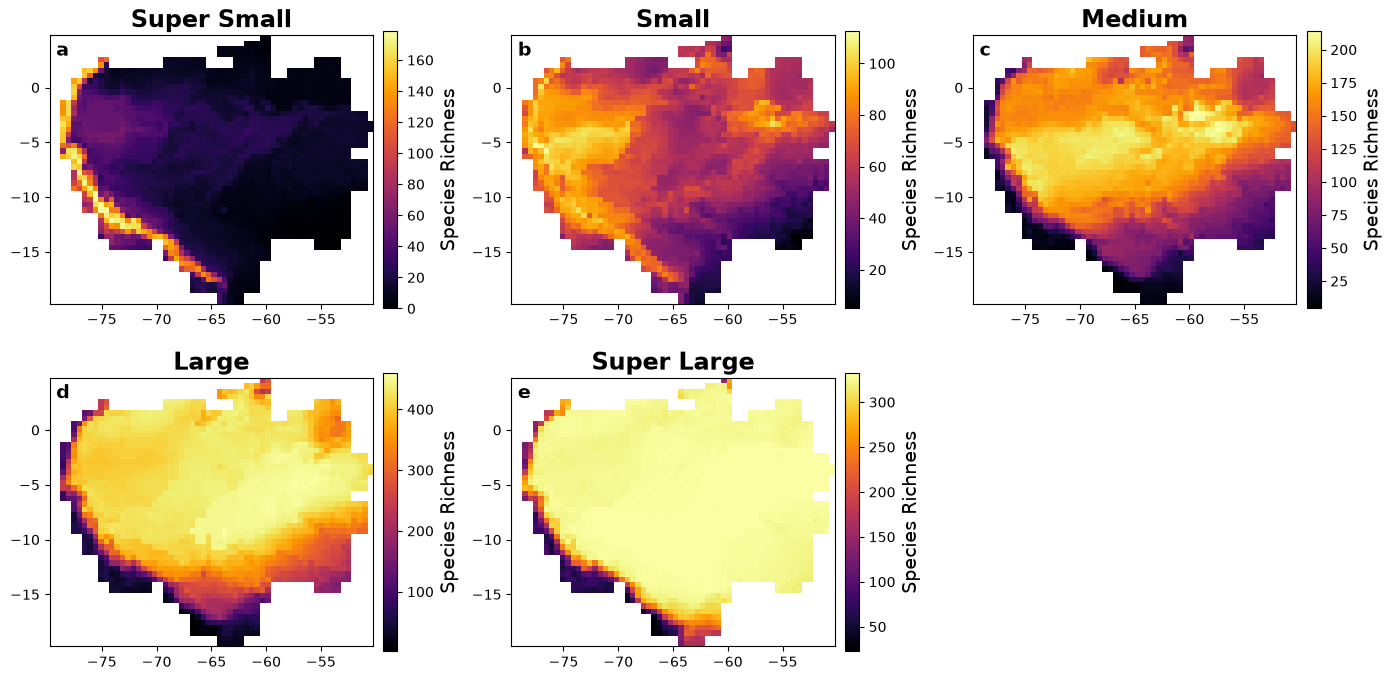

In [ ]:
titles = [
    "Super Small",
    "Small",
    "Medium",
    "Large",
    "Super Large",
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
letters = list(string.ascii_lowercase)

for i, (raster, title) in enumerate(zip(rasters, titles)):
    ax = axes[i]
    im = ax.imshow(
        raster,
        cmap="inferno",
        extent=[
            float(raster.x.min()), float(raster.x.max()),
            float(raster.y.min()), float(raster.y.max()),
        ],
        origin="upper",
    )
    ax.set_title(title, fontsize=17, fontweight="bold")
    ax.text(0.02, 0.98, letters[i], transform=ax.transAxes, fontsize=14,
            fontweight="bold", va="top", ha="left")
    cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.03)
    cbar.ax.set_ylabel("Species Richness", fontsize=14)

fig.delaxes(axes[-1])
fig.tight_layout()
fig.savefig(PLOT_DIR / "sr_by_range_size_class.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
species_types = ["amphibians", "birds_resident", "reptiles", "mammals"]

In [ ]:
# Bounding box
minx, miny, maxx, maxy = -80, -20, -50, 5

rasters_taxa = []
for species_type in species_types:
    sr_path = SPECIES_TYPE_DIR / f"historic_species_richness_mean_{species_type}.tif"
    sr_raster = rxr.open_rasterio(sr_path).squeeze()
    sr_raster_clip = sr_raster.rio.clip_box(minx=minx, miny=miny, maxx=maxx, maxy=maxy)
    rasters_taxa.append(sr_raster_clip)

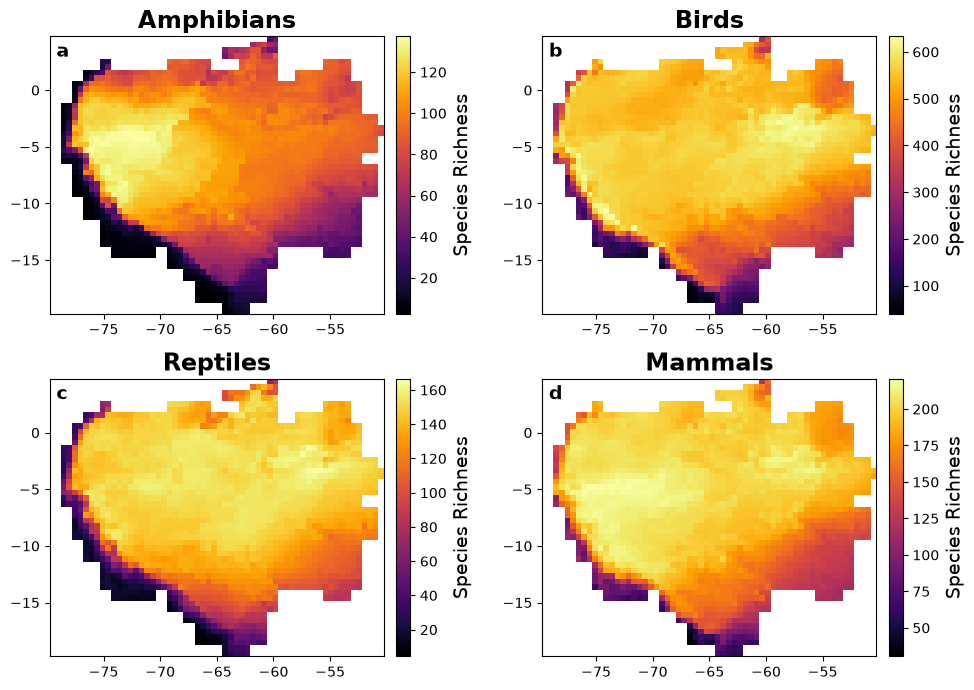

In [ ]:
titles = [
    "Amphibians",
    "Birds",
    "Reptiles",
    "Mammals",
]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

for i, (raster, title) in enumerate(zip(rasters_taxa, titles)):
    ax = axes[i]
    im = ax.imshow(
        raster,
        cmap="inferno",
        extent=[
            float(raster.x.min()), float(raster.x.max()),
            float(raster.y.min()), float(raster.y.max()),
        ],
        origin="upper",
    )
    ax.set_title(title, fontsize=17, fontweight="bold")
    ax.text(0.02, 0.98, letters[i], transform=ax.transAxes, fontsize=14,
            fontweight="bold", va="top", ha="left")
    cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.03)
    cbar.ax.set_ylabel("Species Richness", fontsize=14)

fig.tight_layout()
fig.savefig(PLOT_DIR / "sr_by_taxa.png", dpi=300, bbox_inches="tight")
plt.show()